# The HPC pipeline on a set of sweeps, and the region boundaries

The full DR11 south blind run cuts the sky into about 300–450 regions of about 100 deg²,
one SLURM array task each (`scripts/slurm/rema_dr11_blind.sh`; see the HPC page of the
documentation). This notebook runs the same stages, with the same task script
(`scripts/slurm/rema_task.sh`), on the sweeps of the blind notebook, cut into one region
per sweep. It then measures what the region boundaries change, by comparing the merged
catalogue with the blind notebook's one-region catalogue of the same sweeps and calibration.

**How a cluster near a boundary is handled:**

- A region reads the galaxies and randoms of its *data box*, which is its *own box* grown by
  a 2° buffer, and keeps the clusters whose final centre lies in its own box.
- The own boxes tile the sky without overlap, so the merged catalogue has no duplicates, and
  `MEM_MATCH_ID = region << 32 | rank` is unique.
- Sweeps are only I/O units. A cluster across two sweeps is seen whole by the region that
  owns its centre.
- The 2° buffer covers what changes a cluster directly: its aperture, plus a higher-ranked
  neighbour's mask radius and seed offset, at most about 1.6° at z = 0.05.
- Percolation chains that run beyond the buffer can still change a cluster, at second order.

Run the blind notebook first. With three sweeps the regions take about 1.5 times the
one-region time, because the buffers are read twice.

## Setup and parameters

`SWEEPS` must be the blind notebook's. `OUTDIR` is laid out like an HPC run directory, and
its `galaxies/` points to the per-sweep tables that the blind notebook wrote. The stages run
the task script with the environment variables the driver would set. `AREA_BOX` restricts
the run to the sweeps, `TARGET_AREA=25` with `BAND_HEIGHT=5` gives one region per sweep, and
`NRAND=1` uses one randoms file.

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")   # before importing jax

import dataclasses
import logging
import re
import sys
import time
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from matplotlib.colors import LinearSegmentedColormap

# Persistent compilation cache, shared with the rema command line.
jax.config.update("jax_compilation_cache_dir",
                  os.environ.get("JAX_COMPILATION_CACHE_DIR") or os.path.expanduser("~/.cache/rema/jax"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 1.0)

# Paths: the environment variables, else the CC-IN2P3 locations when /sps is mounted (the Jupyter
# kernels there do not read ~/.bashrc), else a local copy.
CC = Path("/sps/lsst/datasets/desi/legacysurveys")
if CC.exists():
    LS_DIR, WORK_ROOT = CC, Path("/sps/lsst/users") / os.environ.get("USER", "") / "rema"
else:
    LS_DIR, WORK_ROOT = Path("/home/comparat/data/legacysurvey"), Path("/home/comparat/data/rema")
LS_DIR = Path(os.environ.get("LEGACYSURVEY_DIR", LS_DIR))
DR11 = Path(os.environ.get("REMA_DR11_DIR", LS_DIR / "dr11" / "south"))
CALIB = Path(os.environ.get("REMA_CALIB", WORK_ROOT / "calib_dr11_griz_strip_zrmod.fits"))
EXAMPLES = Path(os.environ.get("REMA_WORK", WORK_ROOT / "examples"))

# At most 10 sweeps (5 x 5 deg tiles of DR11 south), not necessarily contiguous. The default is
# the 75 deg^2 strip RA 0-5, Dec -15 to 0 (three sweeps).
SWEEPS = ["sweep-000m005-005p000.fits", "sweep-000m010-005m005.fits", "sweep-000m015-005m010.fits"]
assert 1 <= len(SWEEPS) <= 10, "up to 10 sweeps (larger areas: the HPC pipeline)"

import json
import subprocess

import rema
from rema.calibration import Calibration
from rema.io.tables import read_catalog, read_header
from rema.pipeline import file_sha1, plan_boxes, read_plan, region_path, required_buffer
from rema.sky.regions import sweep_union

TASK = Path(rema.__file__).resolve().parents[1] / "scripts" / "slurm" / "rema_task.sh"
OUTDIR = EXAMPLES / "pipeline"
OUTDIR.mkdir(parents=True, exist_ok=True)
GALDIR = EXAMPLES / "galaxies"
if not (OUTDIR / "galaxies").exists():
    (OUTDIR / "galaxies").symlink_to(GALDIR)

SKY = sweep_union(SWEEPS)
BOUND = SKY.bounding()
area_box = ";".join(f"{b.ra_min:g} {b.ra_max:g} {b.dec_min:g} {b.dec_max:g}" for b in SKY.boxes)
# Products stay in OUTDIR, never in the production folders a sourced ccin2p3.env may point to.
ENV = {**os.environ, "DR11": str(DR11), "OUTDIR": str(OUTDIR), "CALIB": str(CALIB),
       "CLUSTERS_DIR": str(OUTDIR), "MEMBERS_DIR": str(OUTDIR),
       "AREA_BOX": area_box, "TARGET_AREA": "25", "BAND_HEIGHT": "5", "BUFFER": "2",
       "NRAND": "1", "CHUNK": "100000", "DEVICE": "gpu" if jax.default_backend() == "gpu" else "cpu",
       "PATH": f"{Path(sys.executable).parent}:{os.environ['PATH']}"}


def stage(*args):
    """Run one stage of the task script, as a SLURM array task would; returns the seconds."""
    t0 = time.perf_counter()
    print("$ rema_task.sh " + " ".join(map(str, args)))
    r = subprocess.run(["bash", str(TASK), *map(str, args)], env=ENV, capture_output=True, text=True)
    lines = [l for l in r.stderr.splitlines() if " rema" in l and "WARNING" not in l
             and not re.search(r"seeds \(K=|round \d+,", l)]
    print("\n".join("  " + l[9:] for l in lines[-6:]))
    if r.returncode:
        print(r.stderr[-3000:])
        raise RuntimeError(f"stage {args} failed")
    return time.perf_counter() - t0


print(f"rema {rema.__version__}; {len(SWEEPS)} sweeps, {SKY.area_deg2():.1f} deg²; AREA_BOX = {area_box}")
print(f"device for the regions: {ENV['DEVICE']}")

rema 0.1.0; 3 sweeps, 74.1 deg²; AREA_BOX = 0 5 -15 0
device for the regions: gpu


In [2]:
class StageSummaries(logging.Filter):
    """Drop rema's per-batch progress lines; keep the stage summaries."""

    progress = re.compile(r"seeds \(K=|round \d+,")

    def filter(self, record):
        return not self.progress.search(record.getMessage())


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(message)s",
                    datefmt="%H:%M:%S", stream=sys.stdout, force=True)
for handler in logging.getLogger().handlers:
    handler.addFilter(StageSummaries())

# Figures: hairline grid, a one-hue sequential ramp, three categorical colours.
plt.rcParams.update({"figure.dpi": 100, "font.size": 9, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "legend.frameon": False})
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29d"
RAMP = LinearSegmentedColormap.from_list(
    "ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])


def outline(ax, box, **kw):
    """Draw a Box (or each box of a BoxUnion) on RA/Dec axes."""
    for b in box.boxes:
        ax.plot([b.ra_min, b.ra_max, b.ra_max, b.ra_min, b.ra_min],
                [b.dec_min, b.dec_min, b.dec_max, b.dec_max, b.dec_min], **kw)


def label_candidates(ax, x, y, p_cen, r=26):
    """Circle the centre candidates and label them with P_CEN.

    Call after the axis limits are set. Labels point away from the plot centre and are
    turned, when needed, so that they do not overlap.
    """
    ax.scatter(x, y, s=160, facecolor="none", edgecolor=ORANGE, lw=1.5, label="centre candidates")
    ax.apply_aspect()
    to_pt = 72 / ax.figure.dpi
    cx, cy = ax.transData.transform((0, 0)) * to_pt
    placed = []
    for xk, yk, pk in zip(x, y, p_cen):
        px, py = ax.transData.transform((xk, yk)) * to_pt
        base = np.arctan2(py - cy, px - cx) if np.hypot(px - cx, py - cy) > 3 else np.pi / 4
        for turn in (0, 0.6, -0.6, 1.2, -1.2, 1.8, -1.8, 2.4, -2.4, np.pi):
            dx, dy = r * np.cos(base + turn), r * np.sin(base + turn)
            if all(np.hypot(px + dx - qx, py + dy - qy) > 18 for qx, qy in placed):
                break
        placed.append((px + dx, py + dy))
        ax.annotate(f"{pk:.2f}", (xk, yk), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color=GREY, lw=0.6, shrinkA=0, shrinkB=7))


T = {}   # wall-clock time of each step [s]

## Galaxies and randoms, once

On the HPC these two stages are arrays:

- **ingest:** one task per chunk of 20 sweeps, which reads the 1.8 TB of sweeps once;
- **randoms:** one task per randoms file, which reads each 23 GB file once and writes a
  copy of the needed columns sorted by HEALPix pixel.

Afterwards a region's footprint reads only the rows of its data box. Here the per-sweep
tables already exist, so the ingest stage keeps them, and the randoms index covers only the
sweeps (`AREA_BOX`).

In [3]:
T["ingest"] = stage("ingest", 0)
T["randoms"] = stage("randoms", 0)
idx = OUTDIR / "randoms_index"
print(f"randoms index: {json.loads((idx / 'randoms-south-1-0.json').read_text())['nrows']:,} rows")

$ rema_task.sh ingest 0


  2 23:04:04,471 rema INFO 3 per-sweep tables in /home/comparat/data/rema/examples/pipeline/galaxies in 0.5s
$ rema_task.sh randoms 0


  2 23:04:05,250 rema INFO indexed /home/comparat/data/legacysurvey/dr11/south/randoms/randoms-south-1-0.fits -> /home/comparat/data/rema/examples/pipeline/randoms_index/randoms-south-1-0.npy in 0.0s
randoms index: 185,064 rows


## The region plan

`rema regions` plans the regions from the galaxy counts in the per-sweep table headers.

- Dec bands follow the sweep rows: 10° bands in production, 5° here. The polar cap
  (|Dec| > 85°) is one full-RA ring.
- In each band, own boxes are runs of whole sweeps, starting after the largest RA gap so
  that RA 0/360 is handled. Each run holds about `TARGET_AREA` deg².
- Regions above `MAX_GAL` galaxies, or `MAX_PAIRS` estimated percolation pairs, are split.
- Regions are numbered by decreasing estimated cost.

Each data box is the own box grown by the buffer, cut here to the sweeps (`AREA_BOX`). The
planner checks the buffer against `required_buffer`. The *first-order* reach is the
aperture plus a neighbour's mask radius and seed offset. The *exact* reach is percolation's
full dependency radius.

$ rema_task.sh plan


  2 23:04:05,821 rema INFO 3 per-sweep tables, 3 M galaxies, 40850 with ZSPEC
  2 23:04:08,162 rema INFO buffer 2.00 deg; exact reach at z = 0.05: 2.33 deg (lambda 100)
  2 23:04:08,189 rema INFO wrote /home/comparat/data/rema/examples/pipeline/regions.fits: 3 regions; own area 24-25 deg2 (median 25); galaxies in the data box median 1.8 M, max 2.1 M; dependency pairs median 33 M, max 34 M
3 regions, PLANHASH f2f3123dbc94
  region 0: own (0.0, 5.0, -10.0, -5.0), data Dec -12 to -3, 45 deg², 2.06 M galaxies
  region 1: own (0.0, 5.0, -5.0, 0.0), data Dec -7 to 0, 35 deg², 1.81 M galaxies
  region 2: own (0.0, 5.0, -15.0, -10.0), data Dec -15 to -8, 34 deg², 1.44 M galaxies


  λ =  30 at z = 0.05: first-order reach 1.40°, exact 1.89°
  λ = 100 at z = 0.05: first-order reach 1.62°, exact 2.33°
  λ = 300 at z = 0.05: first-order reach 1.87°, exact 2.90°


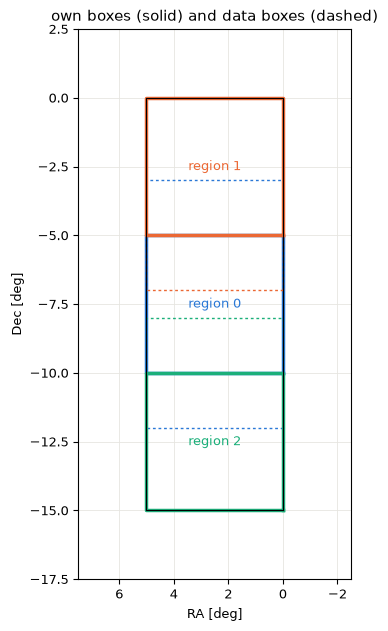

In [4]:
T["plan"] = stage("plan")
plan, meta = read_plan(OUTDIR / "regions.fits")
rids = [int(r) for r in plan["REGION_ID"]]
print(f"{len(rids)} regions, PLANHASH {meta['PLANHASH']}")
for r in rids:
    own, data = plan_boxes(plan, r, meta)
    print(f"  region {r}: own {own.as_tuple()}, data Dec {data.bounding().dec_min:.0f} to "
          f"{data.bounding().dec_max:.0f}, {data.area_deg2():.0f} deg², "
          f"{plan['NGAL_DATA'][rids.index(r)] / 1e6:.2f} M galaxies")
need = {lam: required_buffer(Calibration.read(CALIB).config, lam) for lam in (30, 100, 300)}
for lam, d in need.items():
    print(f"  λ = {lam:3d} at z = 0.05: first-order reach {d['first_order']:.2f}°, exact {d['exact']:.2f}°")

fig, ax = plt.subplots(figsize=(5.2, 6.2), constrained_layout=True)
for k, r in enumerate(rids):
    own, data = plan_boxes(plan, r, meta)
    col = (BLUE, ORANGE, AQUA)[k % 3]
    outline(ax, data, color=col, lw=1, ls=(0, (2, 2)))
    outline(ax, own, color=col, lw=2.5)
    ax.text(0.5 * (own.ra_min + own.ra_max), 0.5 * (own.dec_min + own.dec_max), f"region {r}",
            ha="center", va="center", color=col)
outline(ax, SKY, color="black", lw=0.8)
ax.set(xlim=(BOUND.ra_max + 2.5, BOUND.ra_min - 2.5), ylim=(BOUND.dec_min - 2.5, BOUND.dec_max + 2.5),
       xlabel="RA [deg]", ylabel="Dec [deg]", title="own boxes (solid) and data boxes (dashed)")
ax.set_aspect(1 / np.cos(np.radians(0.5 * (BOUND.dec_min + BOUND.dec_max))))
plt.show()

## The regions

Each region is one task: `rema maps` builds its footprint from the randoms index, and
`rema blind` runs with `--regions/--region-id`. On the HPC the first region runs alone to
fill the shared JAX compilation cache, then the others run in parallel. Here they run one
after the other.

As with the driver, only the missing or stale regions run: those without a catalogue, or
whose catalogue was made with another plan or calibration (`rema status`). Each catalogue's
header records the plan, the calibration, the device and the run statistics.

In [5]:
status = subprocess.run(["rema", "status", "--plan", str(OUTDIR / "regions.fits"), "--runs",
                         str(OUTDIR / "regions"), "--calib", str(CALIB)], env=ENV,
                        capture_output=True, text=True).stdout
todo = [int(i) for i in re.search(r"^todo_ids=(.*)$", status, re.M).group(1).split(",") if i]
print(status.splitlines()[0])
for r in rids:
    if r in todo:
        T[f"region {r}"] = stage("region", r)
rows = []
for r in rids:
    h = read_header(region_path(OUTDIR / "regions", r), 0)
    rows.append((r, h["NCLUSTER"], h["NGAL"], h["NCAND"], h["NDEP"], h["TTOTAL"], h["PEAKRSS"], h["DEVICE"]))
Table(rows=rows, names=("REGION", "NCLUSTER", "NGAL", "NCAND", "NDEP", "TTOTAL", "PEAKRSS", "DEVICE")).pprint(max_width=-1)

done=3 missing=0 stale=0 prime=
REGION NCLUSTER   NGAL  NCAND    NDEP   TTOTAL PEAKRSS DEVICE
------ -------- ------- ------ -------- ------ ------- ------
     0     4478 2078274 108309 37533894  708.6    4.95    gpu
     1     3892 1893857  67443 18976657  401.4    4.15    gpu
     2     4487 1375632  91078 31823020  529.2    4.16    gpu


## Merge and QA

`rema merge` concatenates the region catalogues and checks them:

- every MEM_MATCH_ID is unique;
- every centre lies in its region's own box;
- clusters within 1′ and |Δz| < 0.02(1 + z) of each other in different regions are listed;
- no member lacks a cluster;
- galaxies whose total membership exceeds 1 are counted, within one region and across
  regions;
- all regions used the same rema version, calibration and configuration;
- the cluster density is compared with uniform points, against the distance to internal
  edges.

In [6]:
T["merge"] = stage("merge")
qa = json.loads((OUTDIR / "clusters_dr11_qa.json").read_text())
for k in ("n_regions", "n_done", "n_clusters", "duplicate_ids", "centres_outside_own", "close_pairs",
          "close_pairs_cross_region", "members_without_cluster", "galaxies_pmem_over_1",
          "galaxies_pmem_over_1_cross_region", "versions", "calibrations"):
    print(f"{k:34s} {qa.get(k)}")
merged, mmem, _ = read_catalog(OUTDIR / "clusters_dr11.fits", members=False)

$ rema_task.sh merge


  2 23:04:11,723 rema INFO qa centres_outside_own: 0
  2 23:04:11,723 rema INFO qa close_pairs: 7
  2 23:04:11,723 rema INFO qa close_pairs_cross_region: 0
  2 23:04:11,723 rema INFO qa members_without_cluster: 0
  2 23:04:11,723 rema INFO qa galaxies_pmem_over_1: 0
  2 23:04:11,723 rema INFO qa galaxies_pmem_over_1_cross_region: 0
n_regions                          3
n_done                             3
n_clusters                         12857
duplicate_ids                      0
centres_outside_own                0
close_pairs                        7
close_pairs_cross_region           0
members_without_cluster            0
galaxies_pmem_over_1               0
galaxies_pmem_over_1_cross_region  0
versions                           ['0.1.0']
calibrations                       ['6674856b6363d8057bd3a191c12bc7b7eaab6ea4']


## Boundaries: regions against one region

The blind notebook processed the same sweeps as one region, with the same calibration, so
its catalogue is the reference: a run without internal boundaries. The comparison:

- Clusters are matched by their central galaxy (ID_CENT[0]).
- For each reference cluster, the cell gives the distance to the nearest internal boundary
  between regions.
- It then shows, against that distance, whether the cluster is found with the same centre,
  and how much its λ and z_λ change.

Far from the boundaries, only floating-point noise should remain. The catalogues are made on
the same device, so the arrays have the same shapes, but regions batch their candidates
differently.

In [7]:
ref_path = EXAMPLES / "blind" / "clusters.fits"
ref, _, rh = read_catalog(ref_path, members=False)
assert rh.get("SWEEPS") == ",".join(sorted(SWEEPS))[:1000], "run the blind notebook with the same SWEEPS"
assert rh.get("CALSHA1") == file_sha1(CALIB), "run the blind notebook with the same calibration"

# Distance (deg) to the nearest internal boundary: own-box edges shared by two regions.
owns = [plan_boxes(plan, r, meta)[0] for r in rids]
edges_dec = sorted({b.dec_min for b in owns} & {b.dec_max for b in owns})
edges_ra = sorted({b.ra_min % 360 for b in owns} & {b.ra_max % 360 for b in owns})


def boundary_distance(ra, dec):
    d = np.full(np.size(ra), np.inf)
    for e in edges_dec:
        d = np.minimum(d, np.abs(dec - e))
    for e in edges_ra:
        dra = np.abs((ra - e + 180) % 360 - 180) * np.cos(np.radians(dec))
        d = np.minimum(d, dra)
    return d


dist = boundary_distance(ref["RA"], ref["DEC"])
pos = {int(c): k for k, c in enumerate(merged["ID_CENT"][:, 0])}
found = np.array([int(c) in pos for c in ref["ID_CENT"][:, 0]])
k = np.array([pos.get(int(c), 0) for c in ref["ID_CENT"][:, 0]])
dlam = np.where(found, merged["LAMBDA"][k] / ref["LAMBDA"] - 1, np.nan)
dzl = np.where(found, merged["Z_LAMBDA"][k] - ref["Z_LAMBDA"], np.nan)
print(f"reference: {ref['LAMBDA'].size:,} clusters; merged: {merged['LAMBDA'].size:,}; "
      f"internal boundaries at Dec {edges_dec} and RA {edges_ra}")
bins = np.array([0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 99])
print(" distance [deg]   N(λ≥5)  same centre   N(λ≥20)  same centre   median |Δλ/λ|   max |Δz|")
for lo, hi in zip(bins[:-1], bins[1:]):
    s = (dist >= lo) & (dist < hi)
    s5, s20 = s & (ref["LAMBDA"] >= 5), s & (ref["LAMBDA"] >= 20)
    if not s5.any():
        continue
    f5 = found[s5].mean()
    f20 = found[s20].mean() if s20.any() else np.nan
    g = s5 & found
    print(f"  {lo:4.2f}-{hi:5.2f}     {s5.sum():6d}     {f5:6.1%}     {s20.sum():6d}     {f20:6.1%}"
          f"        {np.nanmedian(np.abs(dlam[g])) if g.any() else np.nan:9.2e}   "
          f"{np.nanmax(np.abs(dzl[g])) if g.any() else np.nan:8.1e}")

reference: 12,857 clusters; merged: 12,857; internal boundaries at Dec [-10.0, -5.0] and RA []
 distance [deg]   N(λ≥5)  same centre   N(λ≥20)  same centre   median |Δλ/λ|   max |Δz|
  0.00- 0.25        402     100.0%         19     100.0%         2.66e-06    3.7e-03
  0.25- 0.50        432     100.0%         40     100.0%         2.79e-06    1.1e-04
  0.50- 1.00        876     100.0%         61     100.0%         4.30e-06    6.9e-02
  1.00- 1.50        894     100.0%         62     100.0%         3.38e-06    1.1e-01
  1.50- 2.00        840     100.0%         69     100.0%         3.33e-06    7.6e-02
  2.00- 3.00       1264     100.0%         93     100.0%         3.13e-06    2.0e-01
  3.00-99.00       1517     100.0%        107     100.0%         3.90e-06    1.0e-01


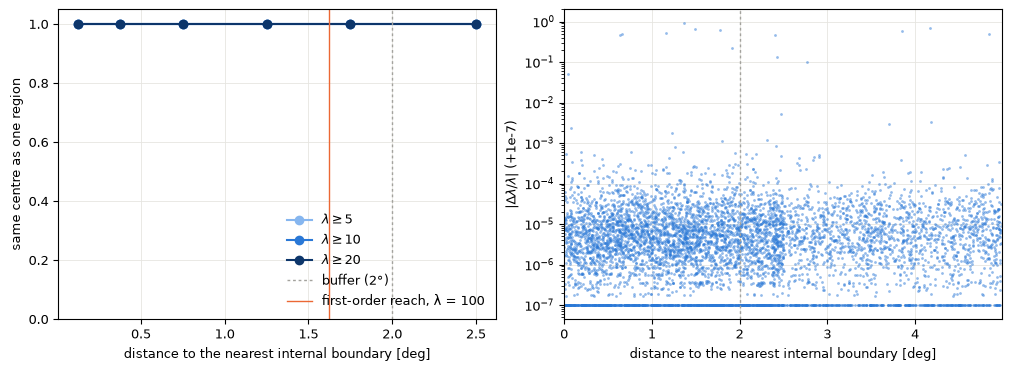

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
mid = 0.5 * (bins[:-2] + bins[1:-1])
for lmin, col in ((5, "#86b6ef"), (10, BLUE), (20, "#0d366b")):
    s = ref["LAMBDA"] >= lmin
    frac = [found[s & (dist >= lo) & (dist < hi)].mean() if np.any(s & (dist >= lo) & (dist < hi))
            else np.nan for lo, hi in zip(bins[:-2], bins[1:-1])]
    ax1.plot(mid, frac, marker="o", color=col, label=rf"$\lambda \geq {lmin}$")
ax1.axvline(2.0, color=GREY, lw=1, ls=(0, (2, 2)), label="buffer (2°)")
ax1.axvline(need[100]["first_order"], color=ORANGE, lw=1, label="first-order reach, λ = 100")
ax1.set(xlabel="distance to the nearest internal boundary [deg]", ylabel="same centre as one region",
        ylim=(0, 1.05))
ax1.legend(loc="lower right")
s = (ref["LAMBDA"] >= 5) & found
ax2.scatter(dist[s], np.abs(dlam[s]) + 1e-7, s=4, color=BLUE, alpha=0.5, lw=0)
ax2.axvline(2.0, color=GREY, lw=1, ls=(0, (2, 2)))
ax2.set(yscale="log", xlabel="distance to the nearest internal boundary [deg]",
        ylabel=r"$|\Delta\lambda / \lambda|$ (+1e-7)", xlim=(0, min(5, dist[np.isfinite(dist)].max())))
plt.show()

Clusters whose z_λ changes by more than 0.01, and how their z_λ iteration ended in the
one-region run (Z_LAMBDA_NITER; the iteration stops at `zlambda.maxiter` = 5 without
converging):

In [9]:
changed = found & (np.abs(dzl) > 0.01)
nit = ref["Z_LAMBDA_NITER"]
cap = Calibration.read(CALIB).config.zlambda.maxiter
print(f"{changed.sum()} clusters with |Δz_λ| > 0.01 ({changed.mean():.2%}); "
      f"{np.sum(changed & (nit >= cap))} of them stopped at maxiter = {cap}, as did "
      f"{np.mean(nit[ref['LAMBDA'] >= 5] >= cap):.0%} of the λ ≥ 5 clusters")
if changed.any():
    t = Table({"LAMBDA": ref["LAMBDA"][changed], "LAMBDA_REGIONS": merged["LAMBDA"][k[changed]],
               "Z_LAMBDA": ref["Z_LAMBDA"][changed], "Z_LAMBDA_REGIONS": merged["Z_LAMBDA"][k[changed]],
               "NITER": nit[changed], "DIST_DEG": dist[changed]})
    for col in t.colnames:
        if t[col].dtype.kind == "f":
            t[col].format = ".3f" if col.startswith("Z") or col == "DIST_DEG" else ".1f"
    t.sort("DIST_DEG")
    t.pprint(max_width=-1, max_lines=30)

15 clusters with |Δz_λ| > 0.01 (0.12%); 15 of them stopped at maxiter = 5, as did 20% of the λ ≥ 5 clusters
LAMBDA LAMBDA_REGIONS Z_LAMBDA Z_LAMBDA_REGIONS NITER DIST_DEG
------ -------------- -------- ---------------- ----- --------
   9.6            5.2    0.709            0.755     5    0.639
   9.3            4.7    0.601            0.532     5    0.661
   9.4            4.4    0.648            0.762     5    1.161
  43.8            4.4    0.769            0.832     5    1.370
  11.9            3.9    0.835            0.894     5    1.487
   8.9            3.3    0.748            0.790     5    1.779
   3.2            3.3    0.813            0.780     5    1.790
   6.9            5.4    0.763            0.687     5    1.914
   5.6            3.0    0.721            0.784     5    2.402
   7.5            6.5    0.706            0.904     5    2.430
   5.5            4.9    0.681            0.781     5    2.771
   4.2            3.4    0.826            0.874     5    3.557
   9.9    

### Reading the comparison

- **Same centre** gives the fraction of reference clusters whose central galaxy is the
  central of a merged cluster. Close to a boundary, a region does not see the percolation
  history beyond its buffer, so a low-λ cluster there can be percolated differently: it may
  lose its candidacy, or be absorbed by, or absorb, a neighbour. The effect fades with
  distance and with richness.
- **Δλ and Δz** for matched clusters measure the same differences at the level of the
  values. Far from every boundary only floating-point noise remains: the regions batch
  their candidates differently, and float32 results change at about 1e-4 with the batch
  composition, which can reorder near-tied candidates.
- A z_λ iteration that stops at the iteration cap has not converged, and the float32 noise
  can send it to another solution, at any distance from a boundary. The table above shows
  whether the changed clusters are of that kind. Z_LAMBDA_NITER flags them in the
  catalogue.

In production, a region is 10° × 10° and its buffer is 2°. Close to the boundaries, the
density profile in the merge QA (`edge_profile`) shows whether clusters are lost or doubled.

## Runtimes

Regions reread their buffers, so with one region per sweep the total area processed is
larger than the sweeps themselves. With 100 deg² regions and 2° buffers the overhead is
about 2×.

In [10]:
for step, sec in T.items():
    print(f"{step:12s} {sec:7.1f} s")
regions_total = sum(float(read_header(region_path(OUTDIR / "regions", r), 0)["TTOTAL"]) for r in rids)
t_one = rh.get("TBLIND")
print(f"blind runs of the regions (headers): {regions_total:.0f} s against {t_one:.0f} s for the "
      f"one-region run" if t_one else f"blind runs of the regions: {regions_total:.0f} s")

ingest           1.2 s
randoms          0.6 s
plan             3.1 s
merge            1.2 s
blind runs of the regions (headers): 1639 s against 837 s for the one-region run


## The same on an HPC

The driver submits these stages as SLURM jobs. Each phase submits only what is missing, and
the run waits for a person to check the calibration between the two phases:

```bash
export DR11=/path/to/legacysurvey/dr11/south OUTDIR=$SCRATCH/rema_dr11 DEVICE=gpu PART_GPU=gpu
scripts/slurm/rema_dr11_blind.sh prepare          # ingest + randoms index (arrays)
rema regions --galaxies $OUTDIR/galaxies --calib-suggest 400 --config scripts/slurm/dr11_south.yaml
CALIB_BOX="150 170 -5 15" scripts/slurm/rema_dr11_blind.sh prepare    # calibration
# check $OUTDIR/calib/plots and the calibration header, then:
CALIB=$OUTDIR/calib/calib.fits scripts/slurm/rema_dr11_blind.sh run   # plan, regions, merge
CALIB=$OUTDIR/calib/calib.fits scripts/slurm/rema_dr11_blind.sh status
```

The calibration box above is only an example: use one that `--calib-suggest` proposes. After
failures or timeouts, rerun the same command, and only the missing or stale regions are
submitted.